In [1]:
import torch
import pandas as pd
import numpy as np
import math
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

In [2]:
# SET SEED FOR REPRODUCIBILITY
SEED = 10

In [3]:
# READ THE DATASET
df = pd.read_csv('diabetes.csv')

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
# CONVERT ALL 0's IN THE TARGET COLUMN TO -1
df.loc[df['Outcome'] == 0, 'Outcome'] = -1

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,-1
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,-1
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
# SCALER TO SCALE THE INPUT VALUES IN THE RANGE [-1,1]
scaler = MinMaxScaler(feature_range=(-1, 1))

In [6]:
# GET THE INPUT
x = scaler.fit_transform(df.drop('Outcome', axis=1))
# GET THE OUTPUT
y = df['Outcome'].values

# SPLIT THE DATASET INTO TRAINING AND TEST SET
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=SEED)

# CONVERT DATA TO PYTORCH TENSORS
x_train = torch.tensor(x_train, dtype=torch.float64)
x_test = torch.tensor(x_test, dtype=torch.float64)
y_train = torch.tensor(y_train, dtype=torch.float64)
y_test = torch.tensor(y_test, dtype=torch.float64)

In [7]:
# LEARNING-RATE / STEP-SIZE
lr = 0.1

# NO. OF ITERATIONS
n_iter = 500

In [8]:
# WEIGHT VECTOR ALSO CONTAINING THE BIAS
# INITIALIZED TO ZERO
w = torch.zeros(x.shape[1], dtype=torch.float64)

In [9]:
# INDICATOR FUNCTION
# IT RETURNS 1 WHEN THE PERCEPTRON MAKES A MISCLASSIFICATION
# OR RETURNS 0 OTHERWISE
def indicator_func(xi,yi,w):
    if yi*(torch.dot(w,xi)) <= 0:
        return 1
    else:
        return 0

In [10]:
# PERCEPTRON LOSS FUNCTION
def loss_func(x,y,w):
    loss = 0

    for i in range(x.shape[0]):
        xi = x[i]
        yi = y[i]
        loss += max(0, -yi*(torch.dot(w,xi)))

    return loss/x.shape[0]

In [11]:
# FUNCTION TO RETURN MODEL PREDICTIONS
def predict(x,w):
    preds = []

    for i in range(x.shape[0]):
        xi = x[i]
        pred = torch.sign(torch.dot(w,xi))
        preds.append(pred)

    return torch.tensor(preds)

In [12]:
test_losses = []

In [13]:
for j in range(n_iter):
    # VECTOR USED TO UPDATE THE WEIGHT VECTOR
    weight_update = torch.zeros_like(w)

    for i in range(x_train.shape[0]):
        # INPUT VECTOR
        xi = x_train[i]
        # TARGET LABEL
        yi = y_train[i]
        # VALUE OF INDICATOR FUNCTION
        ind = indicator_func(xi,yi,w)

        # ADD THE PERCEPTRON UPDATES FOR EACH ITERATION
        weight_update = weight_update + (yi*xi*ind)

    # UPDATE THE WEIGHT VECTOR
    w = w + lr*weight_update

    if j%10 == 0:
        # CALCULATE THE PERCEPTRON LOSS ON THE TEST DATASET
        test_losses.append(loss_func(x_test,y_test,w))

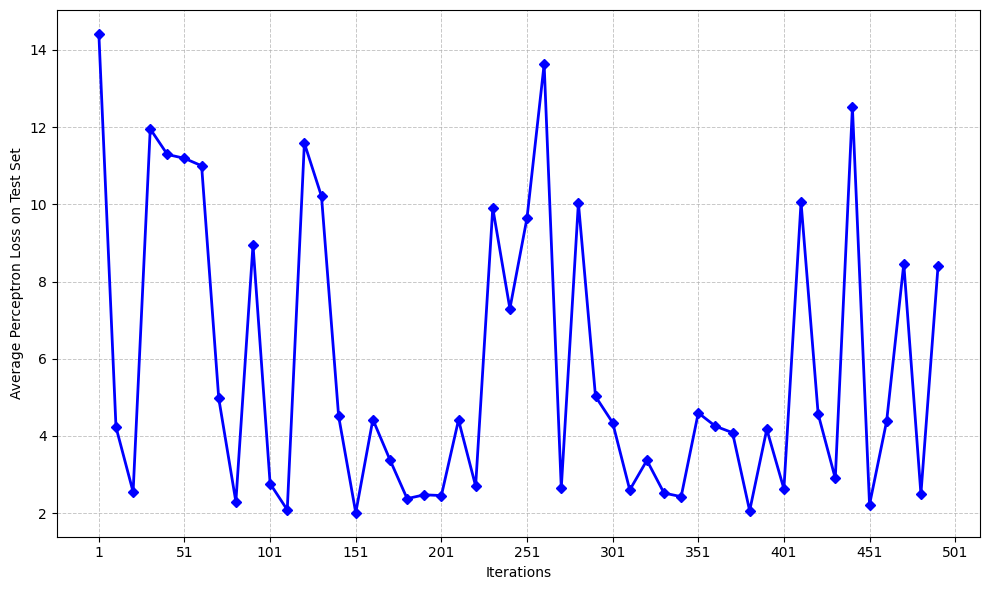

In [14]:
plt.figure(figsize=(10, 6))

plt.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)

plt.plot(list(range(1,500,10)), test_losses, color='b', linestyle='-', linewidth=2, marker='D', markersize=5, label='Test Loss')

plt.xticks(list(range(1,550,50)))
plt.xlabel('Iterations')
plt.ylabel('Average Perceptron Loss on Test Set')
#plt.title('Perceptron Loss on the Test Set')
plt.tight_layout()
plt.show()

In [15]:
# GET THE MODEL PREDICTIONS ON THE TEST SET
preds = predict(x_test,w)

print(f'TEST ACCURACY: {round(accuracy_score(y_test, preds)*100,2)}%')
print(f'TEST PRECISION: {round(precision_score(y_test, preds)*100,2)}%')
print(f'TEST RECALL: {round(recall_score(y_test, preds)*100,2)}%')
print(f'TEST F1: {round(f1_score(y_test, preds)*100,2)}%')

TEST ACCURACY: 70.78%
TEST PRECISION: 55.56%
TEST RECALL: 83.33%
TEST F1: 66.67%


In [16]:
# OUTPUT THE WEIGHT VECTOR
w

tensor([ 9.4941, 34.8161, -6.3246, -1.8141, -8.8513, 25.3052,  9.8517, -0.8500],
       dtype=torch.float64)

POTENTIAL IMPROVEMENTS:-


3.   Change learning rate. Use learning rate scheduler
4.   Consider advanced optimizers such as Adam, RMSprop, AdaGrad
5.   Add L1 or L2 Regularization
6.   Consider ensemble methods


**LEARNING RATE SCHEDULING**

In [17]:
# LEARNING-RATE / STEP-SIZE
lr = 0.1

In [18]:
# WEIGHT VECTOR ALSO CONTAINING THE BIAS
# INITIALIZED TO ZERO
w = torch.zeros(x.shape[1], dtype=torch.float64)

In [19]:
test_losses = []

In [20]:
for j in range(n_iter):
    # VECTOR USED TO UPDATE THE WEIGHT VECTOR
    weight_update = torch.zeros_like(w)

    for i in range(x_train.shape[0]):
        # INPUT VECTOR
        xi = x_train[i]
        # TARGET LABEL
        yi = y_train[i]
        # VALUE OF INDICATOR FUNCTION
        ind = indicator_func(xi,yi,w)

        # ADD THE PERCEPTRON UPDATES FOR EACH ITERATION
        weight_update = weight_update + (yi*xi*ind)

    # UPDATE THE WEIGHT VECTOR
    w = w + lr*weight_update

    if j%200 == 0:
        lr = lr*0.1

    if j%10 == 0:
        # CALCULATE THE PERCEPTRON LOSS ON THE TEST DATASET
        test_losses.append(loss_func(x_test,y_test,w))

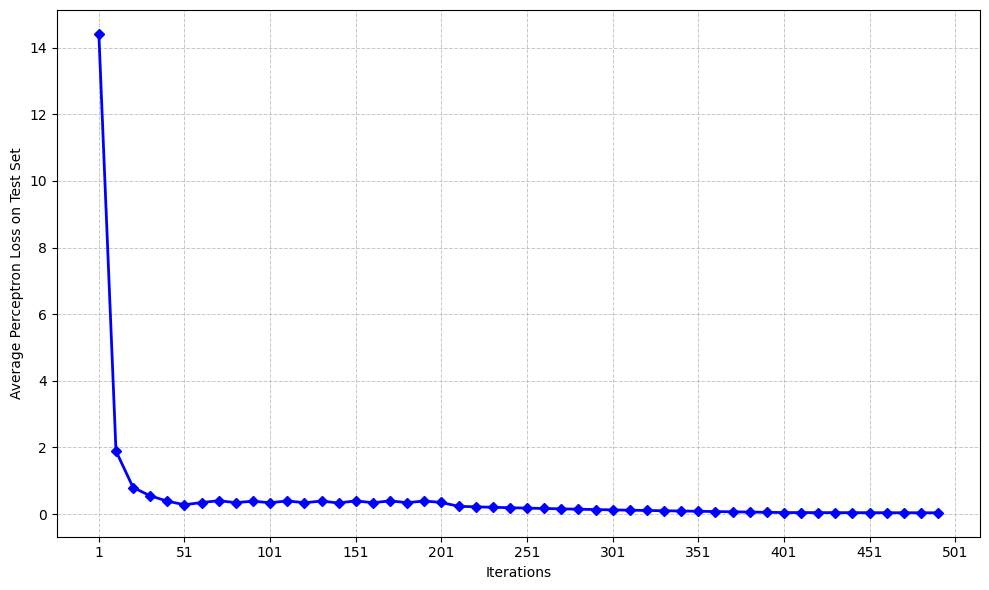

In [21]:
plt.figure(figsize=(10, 6))

plt.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)

plt.plot(list(range(1,500,10)), test_losses, color='b', linestyle='-', linewidth=2, marker='D', markersize=5, label='Test Loss')

plt.xticks(list(range(1,550,50)))
plt.xlabel('Iterations')
plt.ylabel('Average Perceptron Loss on Test Set')
#plt.title('Perceptron Loss on the Test Set')
plt.tight_layout()
plt.show()

In [22]:
# GET THE MODEL PREDICTIONS ON THE TEST SET
preds = predict(x_test,w)

print(f'TEST ACCURACY: {round(accuracy_score(y_test, preds)*100,2)}%')
print(f'TEST PRECISION: {round(precision_score(y_test, preds)*100,2)}%')
print(f'TEST RECALL: {round(recall_score(y_test, preds)*100,2)}%')
print(f'TEST F1: {round(f1_score(y_test, preds)*100,2)}%')

TEST ACCURACY: 82.47%
TEST PRECISION: 74.55%
TEST RECALL: 75.93%
TEST F1: 75.23%


In [23]:
# OUTPUT THE WEIGHT VECTOR
w

tensor([ 0.2388,  0.6246, -0.2697,  0.0401, -0.2475,  0.7684,  0.2985, -0.0096],
       dtype=torch.float64)

**L2 REGULARIZATION**

In [24]:
# LEARNING-RATE / STEP-SIZE
lr = 0.1

# L2 REGULARIZATION PARAMETER
l2_reg = 0.5

In [25]:
# WEIGHT VECTOR ALSO CONTAINING THE BIAS
# INITIALIZED TO ZERO
w = torch.zeros(x.shape[1], dtype=torch.float64)

In [26]:
test_losses = []

In [27]:
for j in range(n_iter):
    # VECTOR USED TO UPDATE THE WEIGHT VECTOR
    weight_update = torch.zeros_like(w)

    for i in range(x_train.shape[0]):
        # INPUT VECTOR
        xi = x_train[i]
        # TARGET LABEL
        yi = y_train[i]
        # VALUE OF INDICATOR FUNCTION
        ind = indicator_func(xi,yi,w)

        # ADD THE PERCEPTRON UPDATES FOR EACH ITERATION
        weight_update = weight_update + (yi*xi*ind)

    # UPDATE THE WEIGHT VECTOR
    w = w + lr*(weight_update - (l2_reg*w))

    if j%200 == 0:
        lr = lr*0.1

    if j%10 == 0:
        # CALCULATE THE PERCEPTRON LOSS ON THE TEST DATASET
        test_losses.append(loss_func(x_test,y_test,w))

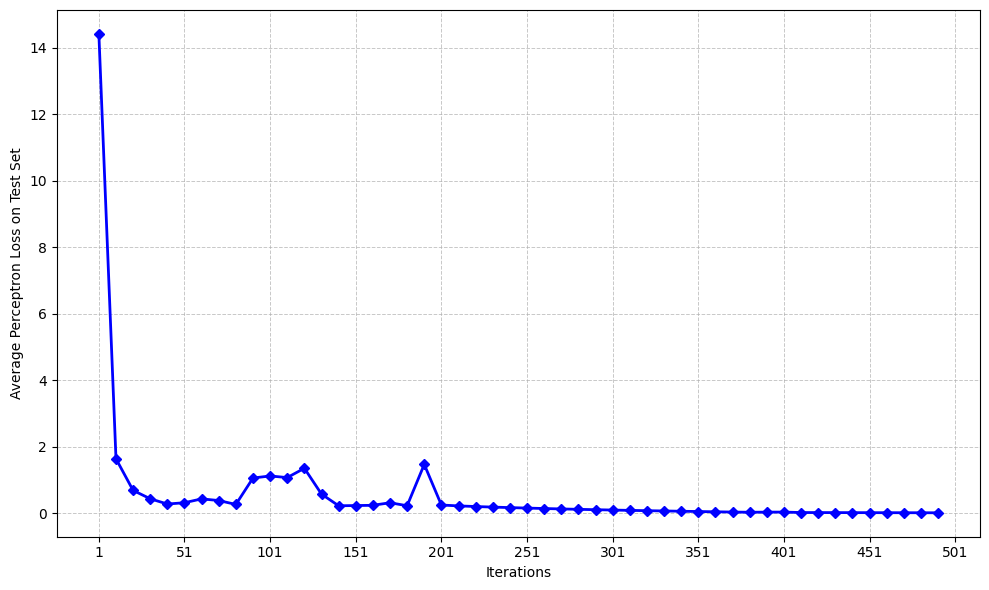

In [28]:
plt.figure(figsize=(10, 6))

plt.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)

plt.plot(list(range(1,500,10)), test_losses, color='b', linestyle='-', linewidth=2, marker='D', markersize=5, label='Test Loss')

plt.xticks(list(range(1,550,50)))
plt.xlabel('Iterations')
plt.ylabel('Average Perceptron Loss on Test Set')
#plt.title('Perceptron Loss on the Test Set')
plt.tight_layout()
plt.show()

In [29]:
# GET THE MODEL PREDICTIONS ON THE TEST SET
preds = predict(x_test,w)

print(f'TEST ACCURACY: {round(accuracy_score(y_test, preds)*100,2)}%')
print(f'TEST PRECISION: {round(precision_score(y_test, preds)*100,2)}%')
print(f'TEST RECALL: {round(recall_score(y_test, preds)*100,2)}%')
print(f'TEST F1: {round(f1_score(y_test, preds)*100,2)}%')

TEST ACCURACY: 82.47%
TEST PRECISION: 73.68%
TEST RECALL: 77.78%
TEST F1: 75.68%


In [30]:
# OUTPUT THE WEIGHT VECTOR
w

tensor([ 0.0857,  0.2365, -0.0984,  0.0046, -0.0848,  0.2925,  0.1142, -0.0028],
       dtype=torch.float64)